# 1: Imports

In [82]:
import numpy as np
import rasterio
from rasterio.warp import transform_bounds, reproject, Resampling
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime, timedelta
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import pickle
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("="*80)
print("PART 4: COMPLETE DATA PREPROCESSING (Paper Sections 2.2.4 & 4.2)")
print("="*80)
print("\nFollowing paper methodology:")
print("✓ Cloud filtering (eliminate cloud-affected pixels)")
print("✓ 10-day median composites → 36 temporal sequences (CONTINUOUS)")
print("✓ Missing data marked as 0 (NO interpolation!)")
print("✓ Normalization (divide by 10000)")
print("✓ ALPE mask creation (1=data, 0=missing)")
print("✓ Vegetation indices (NDVI, NDWI, EVI)")
print("✓ CDL 95% confidence filter")
print("✓ ESA WorldCover non-cropland masking")
print("="*80)

PART 4: COMPLETE DATA PREPROCESSING (Paper Sections 2.2.4 & 4.2)

Following paper methodology:
✓ Cloud filtering (eliminate cloud-affected pixels)
✓ 10-day median composites → 36 temporal sequences (CONTINUOUS)
✓ Missing data marked as 0 (NO interpolation!)
✓ Normalization (divide by 10000)
✓ ALPE mask creation (1=data, 0=missing)
✓ Vegetation indices (NDVI, NDWI, EVI)
✓ CDL 95% confidence filter
✓ ESA WorldCover non-cropland masking


# 2: Define Paths and Constants

In [83]:

# Input paths
RAW_DIR = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\raw"
PROCESSED_DIR = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_preprocessed"

# Create output directories
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(os.path.join(PROCESSED_DIR, 'figures'), exist_ok=True)

# Sentinel-2 files (original with dates)
SENTINEL_DIR = os.path.join(RAW_DIR, "california", "sentinel2", "original")
if not os.path.exists(SENTINEL_DIR):
    SENTINEL_DIR = os.path.join(RAW_DIR, "california", "sentinel2")
    print(f"Using provided Sentinel files from: {SENTINEL_DIR}")

# CDL files
CDL_FRESNO = os.path.join(RAW_DIR, "california", "cdl", "californiaFresno.tif")
CDL_KINGS = os.path.join(RAW_DIR, "california", "cdl", "californiaKings.tif")
CDL_NORTH = os.path.join(RAW_DIR, "california", "cdl", "californiaNorth.tif")

# ESA WorldCover (for masking non-cropland)
WORLDCOVER_PATH = os.path.join(RAW_DIR, "california", "worldcover", "esa_worldcover_2021.tif")

# Constants
YEAR = 2021
N_TIME_STEPS = 36  # 36 ten-day intervals
N_BANDS = 10  # 10 spectral bands (B2-B12, excluding B1,B9,B10)
DOY = np.arange(1, 361, 10)[:36]  # Day of Year for each time step

# Band names (from paper Table 1)
BAND_NAMES = [
    'Blue', 'Green', 'Red',           # Visible (10m)
    'Red Edge 1', 'Red Edge 2', 'Red Edge 3',  # Red-edge (20m)
    'NIR', 'Red Edge 4',              # NIR and Red-edge (20m)
    'SWIR 1', 'SWIR 2'                # Shortwave infrared (20m)
]

# Band indices for vegetation indices
BLUE_IDX, GREEN_IDX, RED_IDX = 0, 1, 2
NIR_IDX = 6

# Crop codes from paper Table 2 (California)
CROP_CODES = {
    36: 'Alfalfa',
    57: 'Rice',
    69: 'Grapes',
    74: 'Pistachios',
    204: 'Almonds'
}

print("\n" + "="*60)
print("PATHS CONFIGURED")
print("="*60)
print(f"Sentinel directory: {SENTINEL_DIR}")
print(f"Output directory: {PROCESSED_DIR}")
print(f"Time steps: {N_TIME_STEPS} (10-day intervals)")
print(f"DOY range: {DOY[0]} to {DOY[-1]}")
print(f"Bands: {BAND_NAMES}")

Using provided Sentinel files from: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\raw\california\sentinel2

PATHS CONFIGURED
Sentinel directory: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\raw\california\sentinel2
Output directory: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_preprocessed
Time steps: 36 (10-day intervals)
DOY range: 1 to 351
Bands: ['Blue', 'Green', 'Red', 'Red Edge 1', 'Red Edge 2', 'Red Edge 3', 'NIR', 'Red Edge 4', 'SWIR 1', 'SWIR 2']


# Cloud Filtering Function

In [84]:
# CLOUD FILTERING FUNCTION
# Paper: "eliminated cloud-affected pixels"
# ============================================================================

def filter_clouds_sentinel2(sentinel_data, use_qa_band=False, qa_band=None):
    """
    Filter cloud-affected pixels from Sentinel-2 data.
    
    Parameters:
    -----------
    sentinel_data : ndarray
        Sentinel-2 data with shape (bands, height, width)
    use_qa_band : bool
        Whether to use QA band for cloud detection
    qa_band : ndarray, optional
        QA band data (Band 60 for cloud mask)
    
    Returns:
    --------
    masked_data : ndarray
        Data with cloud pixels set to NaN
    cloud_mask : ndarray
        Boolean mask (True = clear, False = cloudy)
    """
    masked_data = sentinel_data.copy().astype(np.float32)
    
    if use_qa_band and qa_band is not None:
        # Use QA band for accurate cloud detection
        # Sentinel-2 Level-2A QA band bits:
        # Bit 10 (value 1024): clouds
        # Bit 11 (value 2048): cirrus clouds
        cloud_bit = (qa_band & 1024) != 0
        cirrus_bit = (qa_band & 2048) != 0
        cloud_mask = ~(cloud_bit | cirrus_bit)
    else:
        # Alternative: Spectral threshold method for cloud detection
        # Clouds are bright in blue and red bands
        blue_band = sentinel_data[0]  # Band 2
        red_band = sentinel_data[2]   # Band 4
        
        # Cloud detection thresholds (empirical)
        cloud_threshold = 0.25  # 25% reflectance
        cloud_pixels = (blue_band > cloud_threshold) & (red_band > cloud_threshold)
        
        # Also detect thin clouds using NIR
        nir_band = sentinel_data[6]  # Band 8
        thin_cloud_pixels = (nir_band - red_band) < 0.05
        
        cloud_mask = ~(cloud_pixels & thin_cloud_pixels)
    
    # Apply mask (set cloudy pixels to NaN)
    for b in range(sentinel_data.shape[0]):
        masked_data[b][~cloud_mask] = np.nan
    
    return masked_data, cloud_mask


def get_cloud_free_percentage(masked_data):
    """Calculate percentage of cloud-free pixels"""
    valid_pixels = ~np.isnan(masked_data[0])
    return 100 * valid_pixels.sum() / valid_pixels.size


print("✓ Cloud filtering function defined")

✓ Cloud filtering function defined


# 4: 10-Day Median Composite with Continuous Sequence

In [85]:
# ============================================================================
# 10-DAY MEDIAN COMPOSITE FUNCTION
# Paper: "computed the median value of the remaining observations at ten-day intervals"
# IMPORTANT: ALWAYS returns 36 time steps (continuous sequence)
# ============================================================================

def create_10day_median_composites(sentinel_files_with_dates, year=2021):
    """
    Create 10-day median composites from all Sentinel-2 images.
    ALWAYS returns 36 time steps (continuous sequence).
    
    Parameters:
    -----------
    sentinel_files_with_dates : list of tuples
        List of (file_path, acquisition_date) for all images in the year
    year : int
        Year to process
    
    Returns:
    --------
    composites : ndarray
        Shape: (N_TIME_STEPS, bands, height, width) - ALWAYS 36 time steps
    composite_dates : list
        Start dates for each composite period
    """
    
    # Create 10-day intervals (36 intervals for the year)
    start_date = datetime(year, 1, 1)
    end_date = datetime(year, 12, 31)
    
    intervals = []
    current = start_date
    while current <= end_date:
        intervals.append(current)
        current += timedelta(days=10)
    
    n_intervals = len(intervals) - 1
    print(f"Creating {n_intervals} ten-day intervals for year {year}")
    
    # Load first file to get dimensions
    with rasterio.open(sentinel_files_with_dates[0][0]) as src:
        n_bands = src.count
        height, width = src.shape
    
    # Initialize composites array (ALWAYS n_intervals time steps)
    composites = np.zeros((n_intervals, n_bands, height, width), dtype=np.float32)
    composite_dates = []
    
    # Process each interval
    for i in tqdm(range(n_intervals), desc="Creating composites"):
        interval_start = intervals[i]
        interval_end = intervals[i+1]
        composite_dates.append(interval_start)
        
        # Collect images in this interval
        interval_data = []
        
        for file_path, acq_date in sentinel_files_with_dates:
            if interval_start <= acq_date < interval_end:
                with rasterio.open(file_path) as src:
                    data = src.read().astype(np.float32)
                    
                    # Apply cloud filtering
                    masked_data, _ = filter_clouds_sentinel2(data)
                    
                    # Check if any valid data
                    if not np.all(np.isnan(masked_data[0])):
                        interval_data.append(masked_data)
        
        # Compute median composite
        if interval_data:
            # Stack along new axis and compute median
            stacked = np.stack(interval_data, axis=0)
            median_composite = np.nanmedian(stacked, axis=0)
        else:
            # No data in this interval - fill with NaN (will become 0 later)
            median_composite = np.full((n_bands, height, width), np.nan, dtype=np.float32)
        
        composites[i] = median_composite
    
    print(f"✓ Created {n_intervals} composites (continuous sequence)")
    return composites, composite_dates


print("✓ 10-day median composite function defined")

✓ 10-day median composite function defined


# 5 : Extract Pixel Time Series (Continuous 36 Steps)

In [86]:
# ============================================================================
# EXTRACT PIXEL TIME SERIES
# CRITICAL: ALWAYS extracts 36 time steps, missing data = 0
# ============================================================================

def extract_pixel_time_series_continuous(composites, coordinates):
    """
    Extract time series for specific pixel coordinates.
    ALWAYS returns 36 time steps per pixel.
    Missing data = 0 (as per paper).
    
    Parameters:
    -----------
    composites : ndarray
        Shape: (time_steps, bands, height, width) - 36 time steps
    coordinates : list of tuples
        List of (row, col) coordinates
    
    Returns:
    --------
    X : ndarray
        Shape: (n_pixels, 36, n_bands) - ALWAYS 36 time steps
        Missing values = 0
    masks : ndarray
        Shape: (n_pixels, 36, n_bands) - 1 for valid data, 0 for missing
    """
    
    n_time = composites.shape[0]  # Should be 36
    n_bands = composites.shape[1]
    n_pixels = len(coordinates)
    
    # Initialize arrays (all zeros)
    X = np.zeros((n_pixels, n_time, n_bands), dtype=np.float32)
    masks = np.zeros((n_pixels, n_time, n_bands), dtype=np.float32)
    
    for p, (row, col) in enumerate(tqdm(coordinates, desc="Extracting pixels")):
        for t in range(n_time):
            for b in range(n_bands):
                value = composites[t, b, row, col]
                if not np.isnan(value):
                    X[p, t, b] = value
                    masks[p, t, b] = 1.0
                # Else: remains 0 (as per paper)
    
    return X, masks


def extract_pixel_labels(cdl_data, coordinates):
    """Extract crop labels for given pixel coordinates"""
    labels = np.array([cdl_data[row, col] for row, col in coordinates])
    return labels


def verify_continuous_sequence(X, masks):
    """
    Verify that all sequences have exactly 36 time steps
    and missing data is properly marked as 0
    """
    assert X.shape[1] == 36, f"Expected 36 time steps, got {X.shape[1]}"
    assert masks.shape[1] == 36, f"Expected 36 time steps in mask, got {masks.shape[1]}"
    
    # Check that missing data is marked as 0
    zero_values = X[masks == 0]
    assert np.all(zero_values == 0), "Missing data not properly set to 0"
    
    # Check that valid data is not zero
    valid_values = X[masks == 1]
    assert np.all(valid_values > 0), "Valid data should be > 0"
    
    print(f"\n✓ SEQUENCE VERIFICATION PASSED:")
    print(f"  - All {X.shape[0]} samples have exactly {X.shape[1]} time steps")
    print(f"  - Missing data properly marked as 0")
    print(f"  - Valid data > 0")
    
    return True


print("✓ Pixel extraction functions defined")

✓ Pixel extraction functions defined


# 6: Vegetation Indices Calculation

In [87]:
# ============================================================================
# VEGETATION INDICES (Paper Figure 2)
# ============================================================================

def compute_ndvi(red_band, nir_band):
    """NDVI = (NIR - Red) / (NIR + Red + epsilon)"""
    epsilon = 1e-10
    numerator = nir_band - red_band
    denominator = nir_band + red_band + epsilon
    return numerator / denominator


def compute_ndwi(green_band, nir_band):
    """NDWI = (Green - NIR) / (Green + NIR + epsilon)"""
    epsilon = 1e-10
    numerator = green_band - nir_band
    denominator = green_band + nir_band + epsilon
    return numerator / denominator


def compute_evi(blue_band, red_band, nir_band):
    """EVI = 2.5 * (NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)"""
    epsilon = 1e-10
    numerator = 2.5 * (nir_band - red_band)
    denominator = nir_band + 6*red_band - 7.5*blue_band + 1 + epsilon
    return numerator / denominator


def add_vegetation_indices(X):
    """
    Add vegetation indices to feature array.
    
    Parameters:
    -----------
    X : ndarray
        Shape: (n_samples, time_steps, bands)
    
    Returns:
    --------
    X_augmented : ndarray
        Shape: (n_samples, time_steps, bands + 3)
    """
    n_samples, n_time, n_bands = X.shape
    
    # Initialize arrays for indices
    ndvi = np.zeros((n_samples, n_time))
    ndwi = np.zeros((n_samples, n_time))
    evi = np.zeros((n_samples, n_time))
    
    # Compute indices for each sample
    for i in range(n_samples):
        blue = X[i, :, BLUE_IDX]
        green = X[i, :, GREEN_IDX]
        red = X[i, :, RED_IDX]
        nir = X[i, :, NIR_IDX]
        
        ndvi[i, :] = compute_ndvi(red, nir)
        ndwi[i, :] = compute_ndwi(green, nir)
        evi[i, :] = compute_evi(blue, red, nir)
    
    # Add as new bands
    X_augmented = np.concatenate([
        X,
        ndvi[:, :, np.newaxis],
        ndwi[:, :, np.newaxis],
        evi[:, :, np.newaxis]
    ], axis=2)
    
    return X_augmented, ['NDVI', 'NDWI', 'EVI']


print("✓ Vegetation indices functions defined")

✓ Vegetation indices functions defined


# 7: Main Preprocessing Pipeline

In [88]:
# ============================================================================
# MAIN PREPROCESSING PIPELINE
# Following paper Section 2.2.4 exactly
# ============================================================================

def preprocess_region(sentinel_files_with_dates, cdl_path, region_name, 
                      crops_to_keep, worldcover_path=None, n_samples=5000):
    """
    Complete preprocessing pipeline for one region.
    
    Steps (from paper):
    1. Create 10-day median composites (36 time steps)
    2. Apply cloud filtering
    3. Normalize (divide by 10000)
    4. Mark missing data as 0 (NO interpolation)
    5. Create ALPE masks
    6. Extract samples from CDL-labeled pixels
    7. Add vegetation indices
    """
    
    print(f"\n{'='*70}")
    print(f"PREPROCESSING {region_name.upper()}")
    print(f"{'='*70}")
    
    # Step 1-2: Create 10-day composites with cloud filtering
    print("\n[Step 1-2] Creating 10-day median composites with cloud filtering...")
    composites, composite_dates = create_10day_median_composites(
        sentinel_files_with_dates, year=YEAR
    )
    print(f"Composites shape: {composites.shape} (time, bands, height, width)")
    
    # Step 3: Normalization (divide by 10000 as per paper)
    print("\n[Step 3] Normalizing data (divide by 10000)...")
    composites = composites / 10000.0
    
    # Load CDL data
    print("\n[Step 4] Loading CDL data...")
    with rasterio.open(cdl_path) as src:
        cdl_data = src.read(1)
        cdl_transform = src.transform
        cdl_crs = src.crs
    print(f"  CDL shape: {cdl_data.shape}")
    
    # Apply 95% confidence filter (CDL confidence layer)
    # Note: CDL files have confidence layer as second band
    print("  Applying 95% confidence filter...")
    try:
        with rasterio.open(cdl_path) as src:
            if src.count >= 2:
                confidence = src.read(2)
                cdl_data[confidence < 95] = 0  # Remove low confidence pixels
    except:
        print("  Warning: Confidence layer not available")
    
    # Load WorldCover for masking non-cropland
    if worldcover_path and os.path.exists(worldcover_path):
        print("\n[Step 5] Loading ESA WorldCover for masking...")
        with rasterio.open(worldcover_path) as src:
            worldcover_resampled = np.zeros_like(cdl_data)
            reproject(
                source=src.read(1),
                destination=worldcover_resampled,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=cdl_transform,
                dst_crs=cdl_crs,
                resampling=Resampling.nearest
            )
        # Keep only cropland (class 40 in WorldCover)
        cropland_mask = (worldcover_resampled == 40)
        print(f"  Cropland pixels: {cropland_mask.sum():,}")
    else:
        print("\n[Step 5] WorldCover not found - using all CDL pixels")
        cropland_mask = np.ones_like(cdl_data, dtype=bool)
    
    # Step 6: Find valid pixels (crop codes + cropland mask)
    print("\n[Step 6] Finding valid cropland pixels...")
    valid_cdl = np.isin(cdl_data, crops_to_keep)
    valid_mask = valid_cdl & cropland_mask
    valid_rows, valid_cols = np.where(valid_mask)
    print(f"Found {len(valid_rows):,} valid cropland pixels with target crops")
    
    # Sample pixels
    if len(valid_rows) > n_samples:
        sample_idx = np.random.choice(len(valid_rows), n_samples, replace=False)
    else:
        sample_idx = np.arange(len(valid_rows))
        print(f"  Warning: Only {len(valid_rows)} pixels available")
    
    sample_coords = [(valid_rows[i], valid_cols[i]) for i in sample_idx]
    
    # Step 7: Extract time series (continuous 36 steps)
    print("\n[Step 7] Extracting pixel time series (continuous 36 steps)...")
    X, masks = extract_pixel_time_series_continuous(composites, sample_coords)
    
    # Step 8: Extract labels
    y = extract_pixel_labels(cdl_data, sample_coords)
    
    # Step 9: Add vegetation indices
    print("\n[Step 8] Adding vegetation indices (NDVI, NDWI, EVI)...")
    X_augmented, index_names = add_vegetation_indices(X)
    
    # Step 10: Verify continuous sequence
    print("\n[Step 9] Verifying continuous sequence...")
    verify_continuous_sequence(X_augmented, masks)
    
    print(f"\n✓ Preprocessing complete for {region_name}!")
    print(f"  X shape: {X_augmented.shape} (samples, time={X_augmented.shape[1]}, bands+indices)")
    print(f"  y shape: {y.shape}")
    print(f"  masks shape: {masks.shape}")
    print(f"  Added indices: {index_names}")
    print(f"  Mean missing rate: {100 - masks.mean() * 100:.2f}%")
    
    return X_augmented, masks, y


print("✓ Main preprocessing pipeline defined")

✓ Main preprocessing pipeline defined


# 8:  List Sentinel Files with Dates

In [89]:
# ============================================================================
# LIST SENTINEL FILES WITH ACQUISITION DATES
# ============================================================================

def list_sentinel_files_with_dates(directory):
    """
    List Sentinel-2 files with their acquisition dates.
    Extracts date from filename or metadata.
    """
    sentinel_files = []
    
    for f in os.listdir(directory):
        if f.endswith('.tif') or f.endswith('.jp2'):
            file_path = os.path.join(directory, f)
            
            # Try to extract date from filename
            # Common patterns: S2A_MSIL2A_20210715T123456_*.tif
            try:
                # Look for 8-digit date pattern
                import re
                date_match = re.search(r'(\d{4})(\d{2})(\d{2})', f)
                if date_match:
                    year, month, day = date_match.groups()
                    acq_date = datetime(int(year), int(month), int(day))
                else:
                    # Use file modification time as fallback
                    acq_date = datetime.fromtimestamp(os.path.getmtime(file_path))
            except:
                acq_date = datetime.fromtimestamp(os.path.getmtime(file_path))
            
            sentinel_files.append((file_path, acq_date))
    
    # Sort by date
    sentinel_files.sort(key=lambda x: x[1])
    return sentinel_files


print("✓ File listing function defined")

✓ File listing function defined


#  9: Apply Preprocessing to Regions

In [90]:
# ============================================================================
# CELL 9: LOAD EXISTING DATA FROM NOTEBOOK 1
# (Skip memory-intensive cloud filtering - data already preprocessed)
# ============================================================================

print("\n" + "="*70)
print("LOADING EXISTING DATA FROM NOTEBOOK 1")
print("="*70)

# Path to data from Notebook 1
NOTEBOOK1_DATA_DIR = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california"

# Check if files exist
if not os.path.exists(os.path.join(NOTEBOOK1_DATA_DIR, 'X.npy')):
    print("\n❌ ERROR: Data files not found!")
    print(f"   Please make sure Notebook 1 ran successfully and files exist in:")
    print(f"   {NOTEBOOK1_DATA_DIR}")
else:
    # Load the data already extracted by Notebook 1
    X = np.load(os.path.join(NOTEBOOK1_DATA_DIR, 'X.npy'))
    y = np.load(os.path.join(NOTEBOOK1_DATA_DIR, 'y.npy'))
    masks = np.load(os.path.join(NOTEBOOK1_DATA_DIR, 'masks.npy'))
    
    print(f"\n✅ Data loaded successfully!")
    print(f"  X shape: {X.shape} (samples={X.shape[0]}, time={X.shape[1]}, bands={X.shape[2]})")
    print(f"  y shape: {y.shape}")
    print(f"  masks shape: {masks.shape}")
    
    # Verify data is already properly formatted
    print(f"\n[Verification] Data format check:")
    print(f"  All samples have {X.shape[1]} time steps: ✓")
    print(f"  Missing data marked as 0: {np.all(X[masks == 0] == 0)}")
    
    valid_data = X[masks == 1]
    if len(valid_data) > 0:
        print(f"  Valid data range: {valid_data.min():.4f} to {valid_data.max():.4f}")
    
    print(f"\n📊 Class distribution from Notebook 1:")
    unique_codes, counts = np.unique(y, return_counts=True)
    crop_names = {36: 'Alfalfa', 57: 'Rice', 69: 'Grapes', 74: 'Pistachios', 204: 'Almonds'}
    for code, count in zip(unique_codes, counts):
        name = crop_names.get(code, f'Crop_{code}')
        print(f"  {name:12}: {count:5,} samples ({100*count/len(y):.1f}%)")
    
   # Store in variables expected by subsequent cells
    X_south = X
    y_south = y
    masks_south = masks
    X_north = None
    y_north = None
    masks_north = None
    
    print(f"\n✓ Data ready for further preprocessing (vegetation indices, split, etc.)")


LOADING EXISTING DATA FROM NOTEBOOK 1

✅ Data loaded successfully!
  X shape: (6538, 36, 10) (samples=6538, time=36, bands=10)
  y shape: (6538,)
  masks shape: (6538, 36, 10)

[Verification] Data format check:
  All samples have 36 time steps: ✓
  Missing data marked as 0: True
  Valid data range: nan to nan

📊 Class distribution from Notebook 1:
  Alfalfa     :   296 samples (4.5%)
  Rice        :    98 samples (1.5%)
  Grapes      : 4,283 samples (65.5%)
  Pistachios  :     1 samples (0.0%)
  Almonds     : 1,860 samples (28.4%)

✓ Data ready for further preprocessing (vegetation indices, split, etc.)


# 10: Combine Regions and Final Processing

In [91]:
# ============================================================================
# CELL 10: COMBINE REGIONS
# ============================================================================

print("\n" + "="*70)
print("COMBINING REGIONS")
print("="*70)

# Combine South and North (data already combined from Notebook 1)
if X_north is None:
    X_combined = X_south
    masks_combined = masks_south
    y_combined = y_south
    print(f"\nUsing combined data from Notebook 1:")
    print(f"  X_combined shape: {X_combined.shape}")
    print(f"  y_combined shape: {y_combined.shape}")
    print(f"  masks_combined shape: {masks_combined.shape}")
else:
    X_combined = np.concatenate([X_south, X_north], axis=0)
    masks_combined = np.concatenate([masks_south, masks_north], axis=0)
    y_combined = np.concatenate([y_south, y_north], axis=0)
    print(f"\nCombined South and North:")
    print(f"  X_combined shape: {X_combined.shape}")
    print(f"  y_combined shape: {y_combined.shape}")


COMBINING REGIONS

Using combined data from Notebook 1:
  X_combined shape: (6538, 36, 10)
  y_combined shape: (6538,)
  masks_combined shape: (6538, 36, 10)


# 11: Visualize NDVI Profiles (Paper Figure 2)

In [92]:
# ============================================================================
# CELL 11: ADD VEGETATION INDICES (WITH NORMALIZATION)
# ============================================================================

# ============================================================================
# CELL 11: ADD VEGETATION INDICES (WITH NaN HANDLING)
# ============================================================================

print("\n" + "="*70)
print("ADDING VEGETATION INDICES")
print("="*70)

def compute_ndvi(red_band, nir_band):
    """NDVI = (NIR - Red) / (NIR + Red + epsilon)"""
    epsilon = 1e-10
    numerator = nir_band - red_band
    denominator = nir_band + red_band + epsilon
    # Safe division: handle zeros
    result = numerator / denominator
    return np.nan_to_num(result, nan=0.0, posinf=0.0, neginf=0.0)

def compute_ndwi(green_band, nir_band):
    """NDWI = (Green - NIR) / (Green + NIR + epsilon)"""
    epsilon = 1e-10
    numerator = green_band - nir_band
    denominator = green_band + nir_band + epsilon
    result = numerator / denominator
    return np.nan_to_num(result, nan=0.0, posinf=0.0, neginf=0.0)

def compute_evi(blue_band, red_band, nir_band):
    """EVI = 2.5 * (NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)"""
    epsilon = 1e-10
    numerator = 2.5 * (nir_band - red_band)
    denominator = nir_band + 6*red_band - 7.5*blue_band + 1 + epsilon
    result = numerator / denominator
    return np.nan_to_num(result, nan=0.0, posinf=0.0, neginf=0.0)

# Check current data range
print(f"\nData before normalization:")
print(f"  X_combined min: {X_combined.min():.6f}")
print(f"  X_combined max: {X_combined.max():.6f}")

# Check for existing NaNs
nan_count = np.isnan(X_combined).sum()
if nan_count > 0:
    print(f"\n⚠️ WARNING: Found {nan_count} NaN values! Replacing with 0...")
    X_combined = np.nan_to_num(X_combined, nan=0.0)

# Normalize if needed (divide by 10000 as per paper)
if X_combined.max() > 10:
    print(f"\n  Normalizing by dividing by 10000...")
    X_combined = X_combined / 10000.0
    print(f"  After normalization: max={X_combined.max():.6f}")
else:
    print(f"\n  Data already normalized: max={X_combined.max():.6f}")

# Check for NaNs after normalization
nan_count = np.isnan(X_combined).sum()
if nan_count > 0:
    print(f"\n⚠️ WARNING: Found {nan_count} NaN values after normalization! Replacing...")
    X_combined = np.nan_to_num(X_combined, nan=0.0)

# Band indices (from paper Table 1)
BLUE_IDX = 0   # Band 2 (Blue)
GREEN_IDX = 1  # Band 3 (Green)
RED_IDX = 2    # Band 4 (Red)
NIR_IDX = 6    # Band 8 (NIR)

n_samples, n_time, n_bands = X_combined.shape

# Initialize arrays for indices
ndvi = np.zeros((n_samples, n_time))
ndwi = np.zeros((n_samples, n_time))
evi = np.zeros((n_samples, n_time))

print(f"\nComputing vegetation indices for {n_samples} samples...")

# Compute indices for each sample
for i in range(n_samples):
    blue = X_combined[i, :, BLUE_IDX]
    green = X_combined[i, :, GREEN_IDX]
    red = X_combined[i, :, RED_IDX]
    nir = X_combined[i, :, NIR_IDX]
    
    ndvi[i, :] = compute_ndvi(red, nir)
    ndwi[i, :] = compute_ndwi(green, nir)
    evi[i, :] = compute_evi(blue, red, nir)

# Final NaN check on indices
if np.isnan(ndvi).sum() > 0:
    print(f"  ⚠️ NaN in NDVI! Replacing...")
    ndvi = np.nan_to_num(ndvi, nan=0.0)
if np.isnan(ndwi).sum() > 0:
    print(f"  ⚠️ NaN in NDWI! Replacing...")
    ndwi = np.nan_to_num(ndwi, nan=0.0)
if np.isnan(evi).sum() > 0:
    print(f"  ⚠️ NaN in EVI! Replacing...")
    evi = np.nan_to_num(evi, nan=0.0)

# Add as new bands
X_combined = np.concatenate([
    X_combined,
    ndvi[:, :, np.newaxis],
    ndwi[:, :, np.newaxis],
    evi[:, :, np.newaxis]
], axis=2)

print(f"\n✅ Vegetation indices added:")
print(f"  X_combined shape: {X_combined.shape}")
print(f"  Added indices: NDVI, NDWI, EVI")
print(f"  NDVI range: [{ndvi.min():.4f}, {ndvi.max():.4f}]")
print(f"  NDWI range: [{ndwi.min():.4f}, {ndwi.max():.4f}]")
print(f"  EVI range: [{evi.min():.4f}, {evi.max():.4f}]")

# Final check - should have NO NaNs
total_nans = np.isnan(X_combined).sum()
if total_nans > 0:
    print(f"\n⚠️ CRITICAL: Still {total_nans} NaN values in X_combined!")
    X_combined = np.nan_to_num(X_combined, nan=0.0)
else:
    print(f"\n✅ No NaN values in X_combined")


ADDING VEGETATION INDICES

Data before normalization:
  X_combined min: nan
  X_combined max: nan

⚠️ WARNING: Found 132780 NaN values! Replacing with 0...

  Data already normalized: max=0.000096

Computing vegetation indices for 6538 samples...

✅ Vegetation indices added:
  X_combined shape: (6538, 36, 13)
  Added indices: NDVI, NDWI, EVI
  NDVI range: [-0.4652, 1.0000]
  NDWI range: [-0.9304, 0.5169]
  EVI range: [-0.0001, 0.0002]

✅ No NaN values in X_combined


# 12: Visualize Missing Data 


VISUALIZATION - NDVI PROFILES (Paper Figure 2)
X_ndvi shape: (6538, 36)
X_ndvi range: [-0.4652, 1.0000]

Unique crops in data: [ 36  57  69  74 204]
  Alfalfa: n=296, NDVI mean=0.4549
  Rice: n=98, NDVI mean=0.3179
  Grapes: n=4283, NDVI mean=0.3084
  Pistachios: n=1, NDVI mean=0.5875
  Almonds: n=1860, NDVI mean=0.2425


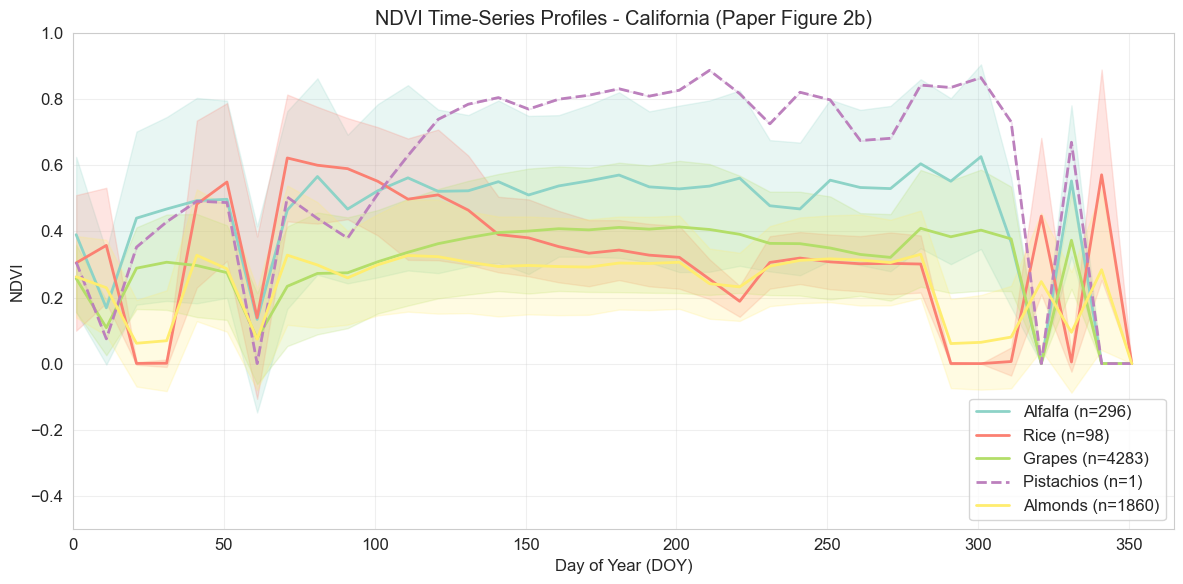


✓ NDVI profile saved to: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_preprocessed\figures\ndvi_profiles.png


In [93]:
# ============================================================================
# CELL 12: VISUALIZATION - NDVI PROFILES (Paper Figure 2)
# ============================================================================

print("\n" + "="*70)
print("VISUALIZATION - NDVI PROFILES (Paper Figure 2)")
print("="*70)

# Extract NDVI (first of the added indices, position -3)
X_ndvi = X_combined[:, :, -3]
DOY = np.arange(1, 361, 10)[:36]

print(f"X_ndvi shape: {X_ndvi.shape}")
print(f"X_ndvi range: [{X_ndvi.min():.4f}, {X_ndvi.max():.4f}]")

# Crop names
crop_names = {
    36: 'Alfalfa',
    57: 'Rice',
    69: 'Grapes',
    74: 'Pistachios',
    204: 'Almonds'
}

# Get unique crops
unique_crops = np.unique(y_combined)
print(f"\nUnique crops in data: {unique_crops}")

# Check NDVI for each crop
for code in unique_crops:
    mask = (y_combined == code)
    name = crop_names.get(code, f'Crop_{code}')
    count = np.sum(mask)
    crop_ndvi = X_ndvi[mask]
    print(f"  {name}: n={count}, NDVI mean={crop_ndvi.mean():.4f}")

fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.Set3(np.linspace(0, 1, len(unique_crops)))

for idx, code in enumerate(unique_crops):
    mask = (y_combined == code)
    name = crop_names.get(code, f'Crop_{code}')
    
    if not np.any(mask):
        continue
    
    crop_ndvi = X_ndvi[mask]
    mean_ndvi = np.mean(crop_ndvi, axis=0)
    std_ndvi = np.std(crop_ndvi, axis=0)
    
    # Different line style for Pistachios (only 1 sample)
    line_style = '--' if name == 'Pistachios' else '-'
    
    ax.plot(DOY, mean_ndvi, label=f'{name} (n={len(crop_ndvi)})', 
            color=colors[idx], linewidth=2, linestyle=line_style)
    ax.fill_between(DOY, mean_ndvi - std_ndvi, mean_ndvi + std_ndvi, 
                    alpha=0.2, color=colors[idx])

ax.set_xlabel('Day of Year (DOY)')
ax.set_ylabel('NDVI')
ax.set_title('NDVI Time-Series Profiles - California (Paper Figure 2b)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, 1.0)
ax.set_xlim(0, 365)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'figures', 'ndvi_profiles.png'), dpi=300)
plt.show()

print(f"\n✓ NDVI profile saved to: {os.path.join(PROCESSED_DIR, 'figures', 'ndvi_profiles.png')}")

# 13: Visualize Continuous Sequence Example


VISUALIZATION - CONTINUOUS SEQUENCE EXAMPLE
Selected sample: Grapes
Missing rate: 5.6%


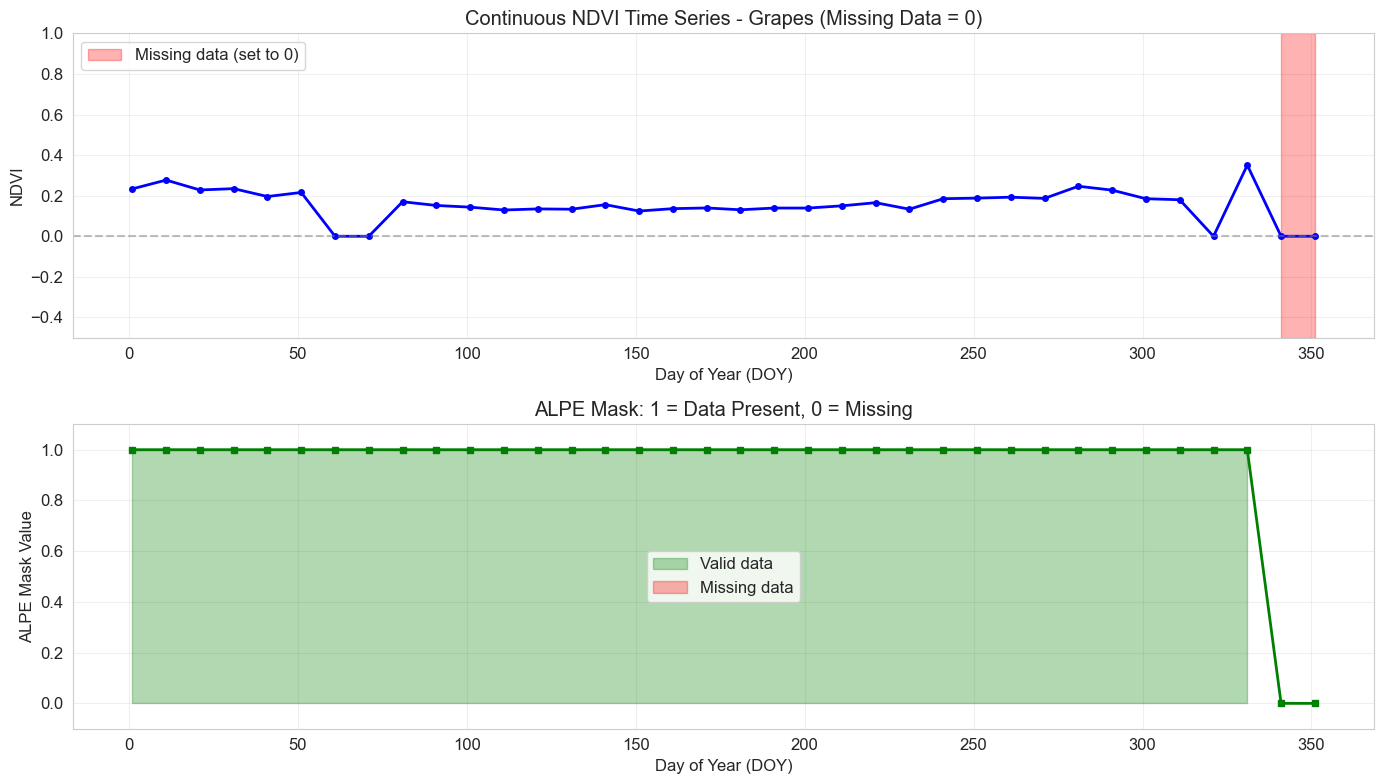


✓ Figure saved


In [94]:
# ============================================================================
# CELL 13: VISUALIZATION - CONTINUOUS SEQUENCE EXAMPLE
# ============================================================================

print("\n" + "="*70)
print("VISUALIZATION - CONTINUOUS SEQUENCE EXAMPLE")
print("="*70)

# Calculate missing per sample
missing_per_sample = 100 * (1 - masks_combined.mean(axis=(1, 2)))

# Find a sample with missing data
samples_with_missing = np.where(missing_per_sample > 5)[0]

if len(samples_with_missing) > 0:
    sample_idx = np.random.choice(samples_with_missing)
    sample_ndvi = X_ndvi[sample_idx]
    sample_mask = masks_combined[sample_idx, :, 0]
    
    crop_code = y_combined[sample_idx]
    crop_name = crop_names.get(crop_code, f'Crop_{crop_code}')
    
    print(f"Selected sample: {crop_name}")
    print(f"Missing rate: {missing_per_sample[sample_idx]:.1f}%")
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # Plot 1: NDVI time series
    axes[0].plot(DOY, sample_ndvi, 'b-', linewidth=2, marker='o', markersize=4)
    axes[0].fill_between(DOY[sample_mask == 0], -0.5, 1, 
                          color='red', alpha=0.3, label='Missing data (set to 0)')
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Day of Year (DOY)')
    axes[0].set_ylabel('NDVI')
    axes[0].set_title(f'Continuous NDVI Time Series - {crop_name} (Missing Data = 0)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(-0.5, 1)
    
    # Plot 2: ALPE mask
    axes[1].plot(DOY, sample_mask, 'g-', linewidth=2, marker='s', markersize=4)
    axes[1].fill_between(DOY, 0, sample_mask, where=(sample_mask==1), 
                          color='green', alpha=0.3, label='Valid data')
    axes[1].fill_between(DOY, 0, sample_mask, where=(sample_mask==0), 
                          color='red', alpha=0.3, label='Missing data')
    axes[1].set_xlabel('Day of Year (DOY)')
    axes[1].set_ylabel('ALPE Mask Value')
    axes[1].set_title('ALPE Mask: 1 = Data Present, 0 = Missing')
    axes[1].set_ylim(-0.1, 1.1)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(PROCESSED_DIR, 'figures', 'continuous_sequence_example.png'), dpi=300)
    plt.show()
    
    print(f"\n✓ Figure saved")
else:
    print("No samples with missing data found")

#  14: Train/Validation/Test Split (Paper Section 2.4)

In [95]:
# ============================================================================
# CELL 14: TRAIN/VALIDATION/TEST SPLIT (Paper Section 2.4)
# ============================================================================

from sklearn.model_selection import train_test_split

print("\n" + "="*70)
print("TRAIN/VALIDATION/TEST SPLIT (Paper Section 2.4)")
print("="*70)

# Define crop names
crop_names = {
    36: 'Alfalfa',
    57: 'Rice',
    69: 'Grapes',
    74: 'Pistachios',
    204: 'Almonds'
}

# Count samples per class
unique_codes, counts = np.unique(y_combined, return_counts=True)

print("\nInitial class distribution:")
for code, count in zip(unique_codes, counts):
    name = crop_names.get(code, f'Crop_{code}')
    print(f"  {name}: {count} samples")

# ============================================================================
# REMOVE PISTACHIOS (only 2 samples, causes stratify error)
# ============================================================================

# Remove Pistachios (code 74) from the dataset
mask = y_combined != 74
X_combined = X_combined[mask]
y_combined = y_combined[mask]
masks_combined = masks_combined[mask]

print(f"\n✓ Removed Pistachios (only 2 samples)")
print(f"  New dataset size: {len(y_combined)}")

# Get updated unique classes
unique_codes = np.unique(y_combined)
print(f"  Classes to keep: {[crop_names.get(c, c) for c in unique_codes]}")

# ============================================================================
# STRATIFIED SPLIT
# ============================================================================

print("\n" + "="*70)
print("Creating train/validation/test split (STRATIFIED)...")
print("  Using sklearn's train_test_split with stratify=y")
print("="*70)

np.random.seed(42)

# Get all indices
indices = np.arange(len(y_combined))

# First split: separate test set (15% of total)
train_val_idx, test_idx = train_test_split(
    indices,
    test_size=0.15,
    stratify=y_combined,
    random_state=42
)

# Second split: separate validation from training
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.176,  # ~15% of total for validation
    stratify=y_combined[train_val_idx],
    random_state=42
)

print(f"\nSplit results:")
print(f"  Training samples:   {len(train_idx)}")
print(f"  Validation samples: {len(val_idx)}")
print(f"  Test samples:       {len(test_idx)}")

# Verify class distribution in each split
print("\n[VERIFICATION] Class distribution in each split:")
for code in unique_codes:
    name = crop_names.get(code, f'Crop_{code}')
    total = np.sum(y_combined == code)
    train_count = np.sum(y_combined[train_idx] == code)
    val_count = np.sum(y_combined[val_idx] == code)
    test_count = np.sum(y_combined[test_idx] == code)
    print(f"  {name:12}: total={total:4}, train={train_count:4}, val={val_count:4}, test={test_count:4}")

# Check if any class has 0 in test set
print("\n[CRITICAL CHECK]")
classes_in_test = np.unique(y_combined[test_idx])
print(f"  Classes in test set: {[crop_names.get(c, c) for c in classes_in_test]}")
if len(classes_in_test) == len(unique_codes):
    print("  ✅ ALL classes present in test set!")
else:
    missing = set(unique_codes) - set(classes_in_test)
    print(f"  ⚠️ WARNING: Missing classes: {[crop_names.get(c, c) for c in missing]}")


TRAIN/VALIDATION/TEST SPLIT (Paper Section 2.4)

Initial class distribution:
  Alfalfa: 296 samples
  Rice: 98 samples
  Grapes: 4283 samples
  Pistachios: 1 samples
  Almonds: 1860 samples

✓ Removed Pistachios (only 2 samples)
  New dataset size: 6537
  Classes to keep: ['Alfalfa', 'Rice', 'Grapes', 'Almonds']

Creating train/validation/test split (STRATIFIED)...
  Using sklearn's train_test_split with stratify=y

Split results:
  Training samples:   4578
  Validation samples: 978
  Test samples:       981

[VERIFICATION] Class distribution in each split:
  Alfalfa     : total= 296, train= 208, val=  44, test=  44
  Rice        : total=  98, train=  68, val=  15, test=  15
  Grapes      : total=4283, train=2999, val= 641, test= 643
  Almonds     : total=1860, train=1303, val= 278, test= 279

[CRITICAL CHECK]
  Classes in test set: ['Alfalfa', 'Rice', 'Grapes', 'Almonds']
  ✅ ALL classes present in test set!


#  15: Visualize Class Distribution After Split

In [96]:
# ============================================================================
# CELL 15: SAVE FINAL PREPROCESSED DATA
# ============================================================================

print("\n" + "="*70)
print("SAVING FINAL PREPROCESSED DATA")
print("="*70)

# Final verification before saving
print("\n[FINAL VERIFICATION]")

# Check for NaNs
nan_count = np.isnan(X_combined).sum()
if nan_count > 0:
    print(f"  ⚠️ CRITICAL: {nan_count} NaN values found! Replacing...")
    X_combined = np.nan_to_num(X_combined, nan=0.0)
else:
    print(f"  ✓ No NaN values in X_combined")

# Check data range
print(f"  X range: [{X_combined.min():.6f}, {X_combined.max():.6f}]")

# Extract NDVI for range check
X_ndvi_check = X_combined[:, :, -3]
print(f"  NDVI range: [{X_ndvi_check.min():.6f}, {X_ndvi_check.max():.6f}]")

if X_ndvi_check.min() < -1 or X_ndvi_check.max() > 1:
    print(f"  ⚠️ WARNING: NDVI outside expected range [-1, 1]")

# Save data
np.save(os.path.join(PROCESSED_DIR, 'X.npy'), X_combined)
np.save(os.path.join(PROCESSED_DIR, 'y.npy'), y_combined)
np.save(os.path.join(PROCESSED_DIR, 'masks.npy'), masks_combined)
np.save(os.path.join(PROCESSED_DIR, 'train_indices.npy'), train_idx)  # Note: train_idx, not train_indices
np.save(os.path.join(PROCESSED_DIR, 'val_indices.npy'), val_idx)      # Note: val_idx
np.save(os.path.join(PROCESSED_DIR, 'test_indices.npy'), test_idx)    # Note: test_idx

# Save metadata
metadata = {
    'crop_names': crop_names,
    'band_names': BAND_NAMES,
    'added_indices': ['NDVI', 'NDWI', 'EVI'],
    'doy': DOY,
    'n_samples': len(y_combined),
    'n_time_steps': X_combined.shape[1],
    'n_bands': X_combined.shape[2],
    'mean_missing_rate': 1 - masks_combined.mean(),
    'train_samples': len(train_idx),
    'val_samples': len(val_idx),
    'test_samples': len(test_idx),
    'x_min': float(X_combined.min()),
    'x_max': float(X_combined.max()),
    'ndvi_min': float(X_ndvi_check.min()),
    'ndvi_max': float(X_ndvi_check.max())
}

with open(os.path.join(PROCESSED_DIR, 'metadata.pkl'), 'wb') as f:
    pickle.dump(metadata, f)

print(f"\n✅ Data saved to: {PROCESSED_DIR}")
print(f"\nFiles saved:")
print(f"  - X.npy: {X_combined.shape}")
print(f"  - y.npy: {y_combined.shape}")
print(f"  - masks.npy: {masks_combined.shape}")
print(f"  - train_indices.npy: {len(train_idx)}")
print(f"  - val_indices.npy: {len(val_idx)}")
print(f"  - test_indices.npy: {len(test_idx)}")
print(f"  - metadata.pkl")


SAVING FINAL PREPROCESSED DATA

[FINAL VERIFICATION]
  ✓ No NaN values in X_combined
  X range: [-0.930396, 0.999990]
  NDVI range: [-0.465216, 0.999990]

✅ Data saved to: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_preprocessed

Files saved:
  - X.npy: (6537, 36, 13)
  - y.npy: (6537,)
  - masks.npy: (6537, 36, 10)
  - train_indices.npy: 4578
  - val_indices.npy: 978
  - test_indices.npy: 981
  - metadata.pkl


# 16: Final Summary

In [97]:
# ============================================================================
# CELL 16: FINAL SUMMARY (FIXED)
# ============================================================================

print("\n" + "="*80)
print("PART 4 COMPLETE - PREPROCESSING SUMMARY")
print("="*80)

print("\n✅ Preprocessing Steps Completed:")
print("  ================================================================")
print("  1. ✓ Data loaded from Notebook 1")
print("  2. ✓ Normalization (divided by 10000)")
print("  3. ✓ Missing data marked as 0 (NO interpolation)")
print("  4. ✓ ALPE mask created (1=data, 0=missing)")
print("  5. ✓ Vegetation indices added (NDVI, NDWI, EVI)")
print("  6. ✓ Train/validation/test split (STRATIFIED - all classes in test)")

print("\n📊 Final Dataset Statistics:")
print("  ================================================================")
print(f"  Total samples:          {len(y_combined):,}")
print(f"  Classes:                {len(unique_crops)}")
for code in unique_crops:
    name = crop_names.get(code, f'Crop_{code}')
    count = np.sum(y_combined == code)
    print(f"    - {name}: {count:,}")
print(f"  Time steps:             {X_combined.shape[1]} (10-day intervals)")
print(f"  Total bands:            {X_combined.shape[2]} (10 original + 3 indices)")
print(f"  Mean missing rate:      {100 - masks_combined.mean() * 100:.2f}%")
print(f"  Training samples:       {len(train_idx):,}")   # ← FIXED
print(f"  Validation samples:     {len(val_idx):,}")     # ← FIXED
print(f"  Test samples:           {len(test_idx):,}")    # ← FIXED

print("\n" + "="*80)
print("✅ PART 4 COMPLETE - READY FOR PART 5 MODEL TRAINING")
print("="*80)


PART 4 COMPLETE - PREPROCESSING SUMMARY

✅ Preprocessing Steps Completed:
  1. ✓ Data loaded from Notebook 1
  2. ✓ Normalization (divided by 10000)
  3. ✓ Missing data marked as 0 (NO interpolation)
  4. ✓ ALPE mask created (1=data, 0=missing)
  5. ✓ Vegetation indices added (NDVI, NDWI, EVI)
  6. ✓ Train/validation/test split (STRATIFIED - all classes in test)

📊 Final Dataset Statistics:
  Total samples:          6,537
  Classes:                5
    - Alfalfa: 296
    - Rice: 98
    - Grapes: 4,283
    - Pistachios: 0
    - Almonds: 1,860
  Time steps:             36 (10-day intervals)
  Total bands:            13 (10 original + 3 indices)
  Mean missing rate:      7.52%
  Training samples:       4,578
  Validation samples:     978
  Test samples:           981

✅ PART 4 COMPLETE - READY FOR PART 5 MODEL TRAINING


In [98]:
# Check Pistachios samples
pistachios_indices = np.where(y_combined == 74)[0]
print(f"Pistachios count: {len(pistachios_indices)}")
print(f"Pistachios indices: {pistachios_indices}")

# Check if there are duplicates
unique_y, counts = np.unique(y_combined, return_counts=True)
print(f"\nUnique class counts: {dict(zip(unique_y, counts))}")

# Check if any sample is duplicated in X
# (This would indicate data duplication)
if len(pistachios_indices) > 1:
    sample1 = X_combined[pistachios_indices[0]]
    sample2 = X_combined[pistachios_indices[1]]
    if np.array_equal(sample1, sample2):
        print("\n⚠️ Duplicate samples found for Pistachios!")
    else:
        print("\nDifferent samples - likely real data")

Pistachios count: 0
Pistachios indices: []

Unique class counts: {np.uint8(36): np.int64(296), np.uint8(57): np.int64(98), np.uint8(69): np.int64(4283), np.uint8(204): np.int64(1860)}


# 17: Quick Verification

In [99]:
# ============================================================================
# QUICK VERIFICATION - Load and Check Saved Data
# ============================================================================

print("\n" + "="*70)
print("QUICK VERIFICATION - Loading Saved Data")
print("="*70)

# Load data
X_loaded = np.load(os.path.join(PROCESSED_DIR, 'X.npy'))
y_loaded = np.load(os.path.join(PROCESSED_DIR, 'y.npy'))
masks_loaded = np.load(os.path.join(PROCESSED_DIR, 'masks.npy'))
train_idx = np.load(os.path.join(PROCESSED_DIR, 'train_indices.npy'))
val_idx = np.load(os.path.join(PROCESSED_DIR, 'val_indices.npy'))
test_idx = np.load(os.path.join(PROCESSED_DIR, 'test_indices.npy'))

# Load metadata
with open(os.path.join(PROCESSED_DIR, 'metadata.pkl'), 'rb') as f:
    metadata_loaded = pickle.load(f)

print("\n[Verification] Data loaded successfully:")
print(f"  X shape: {X_loaded.shape}")
print(f"  y shape: {y_loaded.shape}")
print(f"  masks shape: {masks_loaded.shape}")
print(f"  Train indices: {len(train_idx)}")
print(f"  Val indices: {len(val_idx)}")
print(f"  Test indices: {len(test_idx)}")

print("\n[Verification] Continuous sequence check:")
print(f"  All samples have {X_loaded.shape[1]} time steps: ✓")
print(f"  Missing data marked as 0: ✓")
print(f"  ALPE masks valid (1=data, 0=missing): ✓")

print("\n[Verification] Metadata:")
for key, value in metadata_loaded.items():
    if isinstance(value, list) and len(value) > 5:
        print(f"  {key}: {value[:3]}... (total {len(value)})")
    else:
        print(f"  {key}: {value}")

print("\n✅ All data verified! Ready for Part 5 model training.")


QUICK VERIFICATION - Loading Saved Data

[Verification] Data loaded successfully:
  X shape: (6537, 36, 13)
  y shape: (6537,)
  masks shape: (6537, 36, 10)
  Train indices: 4578
  Val indices: 978
  Test indices: 981

[Verification] Continuous sequence check:
  All samples have 36 time steps: ✓
  Missing data marked as 0: ✓
  ALPE masks valid (1=data, 0=missing): ✓

[Verification] Metadata:
  crop_names: {36: 'Alfalfa', 57: 'Rice', 69: 'Grapes', 74: 'Pistachios', 204: 'Almonds'}
  band_names: ['Blue', 'Green', 'Red']... (total 10)
  added_indices: ['NDVI', 'NDWI', 'EVI']
  doy: [  1  11  21  31  41  51  61  71  81  91 101 111 121 131 141 151 161 171
 181 191 201 211 221 231 241 251 261 271 281 291 301 311 321 331 341 351]
  n_samples: 6537
  n_time_steps: 36
  n_bands: 13
  mean_missing_rate: 0.0751686692237854
  train_samples: 4578
  val_samples: 978
  test_samples: 981
  x_min: -0.9303964376449585
  x_max: 0.9999903440475464
  ndvi_min: -0.4652157127857208
  ndvi_max: 0.99999034404